# Mission Health: Diabetes risk screening

**MCA 521-4 Machine Learning — CIA 3**  
**Mission:** Health | **Task:** Binary classification | **Seed:** 42

- Full results are from the untouched test set.
- Training: `train.py` | Demo: `app.py` | Code: `src/`

In [1]:
from pathlib import Path
import json, sys, joblib
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
sys.path.insert(0, str(ROOT))
DATA = ROOT / 'dataset' / 'diabetes_binary_health_indicators_BRFSS2015.csv'
TABLES = ROOT / 'results' / 'tables'
FIGURES = ROOT / 'results' / 'figures'
ARTIFACTS = ROOT / 'artifacts'
print(f'Project root: {ROOT}')

Project root: /mnt/data/college/4_tri/ML-Lab-2547121/ML_CIA


## Q1 — Real-world impact framing

- **Problem:** Clinics with limited resources cannot test everyone at once.
- **Goal:** Find adults who should receive diabetes testing first.
- **Beneficiaries:** Adults at risk, mainly those with cost or access problems.
- **Unit and target:** One BRFSS participant; `Diabetes_binary` is 0 or 1.
- **Measures:** PR-AUC, ROC-AUC, recall, precision, F2 and missed cases.
- **Why ML:** Health and lifestyle factors can have complex links with diabetes.
- **Data:** UCI *CDC Diabetes Health Indicators*, 253,680 rows and 21 features. [DOI](https://doi.org/10.24432/C53919)
- **Limit:** Screening support only; not diagnosis or future-risk prediction.

In [2]:
df = pd.read_csv(DATA)
audit = json.loads((TABLES / 'data_audit.json').read_text())
summary = pd.Series({
    'raw rows': audit['raw_rows'],
    'features': audit['columns'] - 1,
    'missing cells': audit['missing_cells'],
    'exact duplicates removed': audit['rows_removed'],
    'rows modelled': audit['rows_after_exact_deduplication'],
    'positive rate after deduplication': audit['positive_rate_after_deduplication'],
})
display(summary.to_frame('value'))
display(pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(), 'unique': df.nunique(), 'min': df.min(), 'max': df.max()}))

,value
raw rows,253680.000000
features,21.000000
missing cells,0.000000
exact duplicates removed,24206.000000
rows modelled,229474.000000
positive rate after deduplication,0.152945


,dtype,missing,unique,min,max
Diabetes_binary,float64,0,2,0.0,1.0
HighBP,float64,0,2,0.0,1.0
HighChol,float64,0,2,0.0,1.0
CholCheck,float64,0,2,0.0,1.0
BMI,float64,0,84,12.0,98.0
Smoker,float64,0,2,0.0,1.0
Stroke,float64,0,2,0.0,1.0
HeartDiseaseorAttack,float64,0,2,0.0,1.0
PhysActivity,float64,0,2,0.0,1.0
Fruits,float64,0,2,0.0,1.0


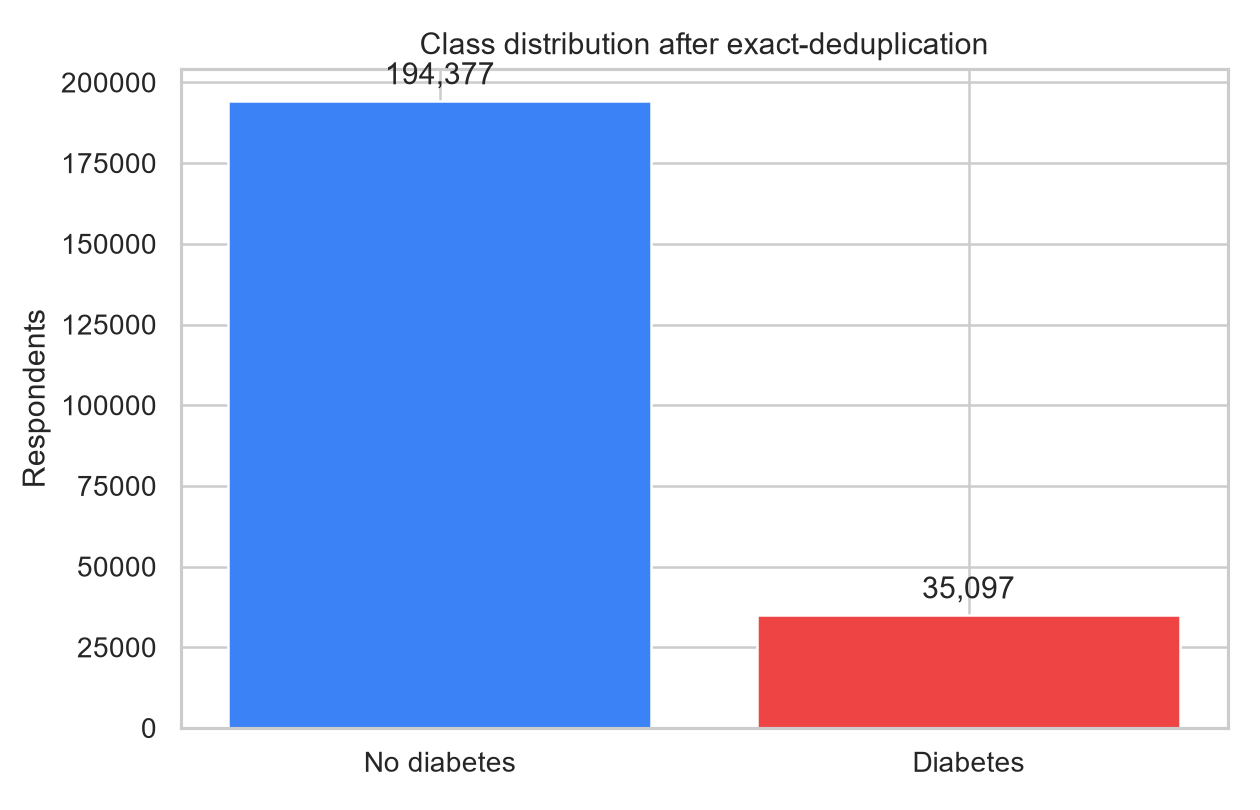

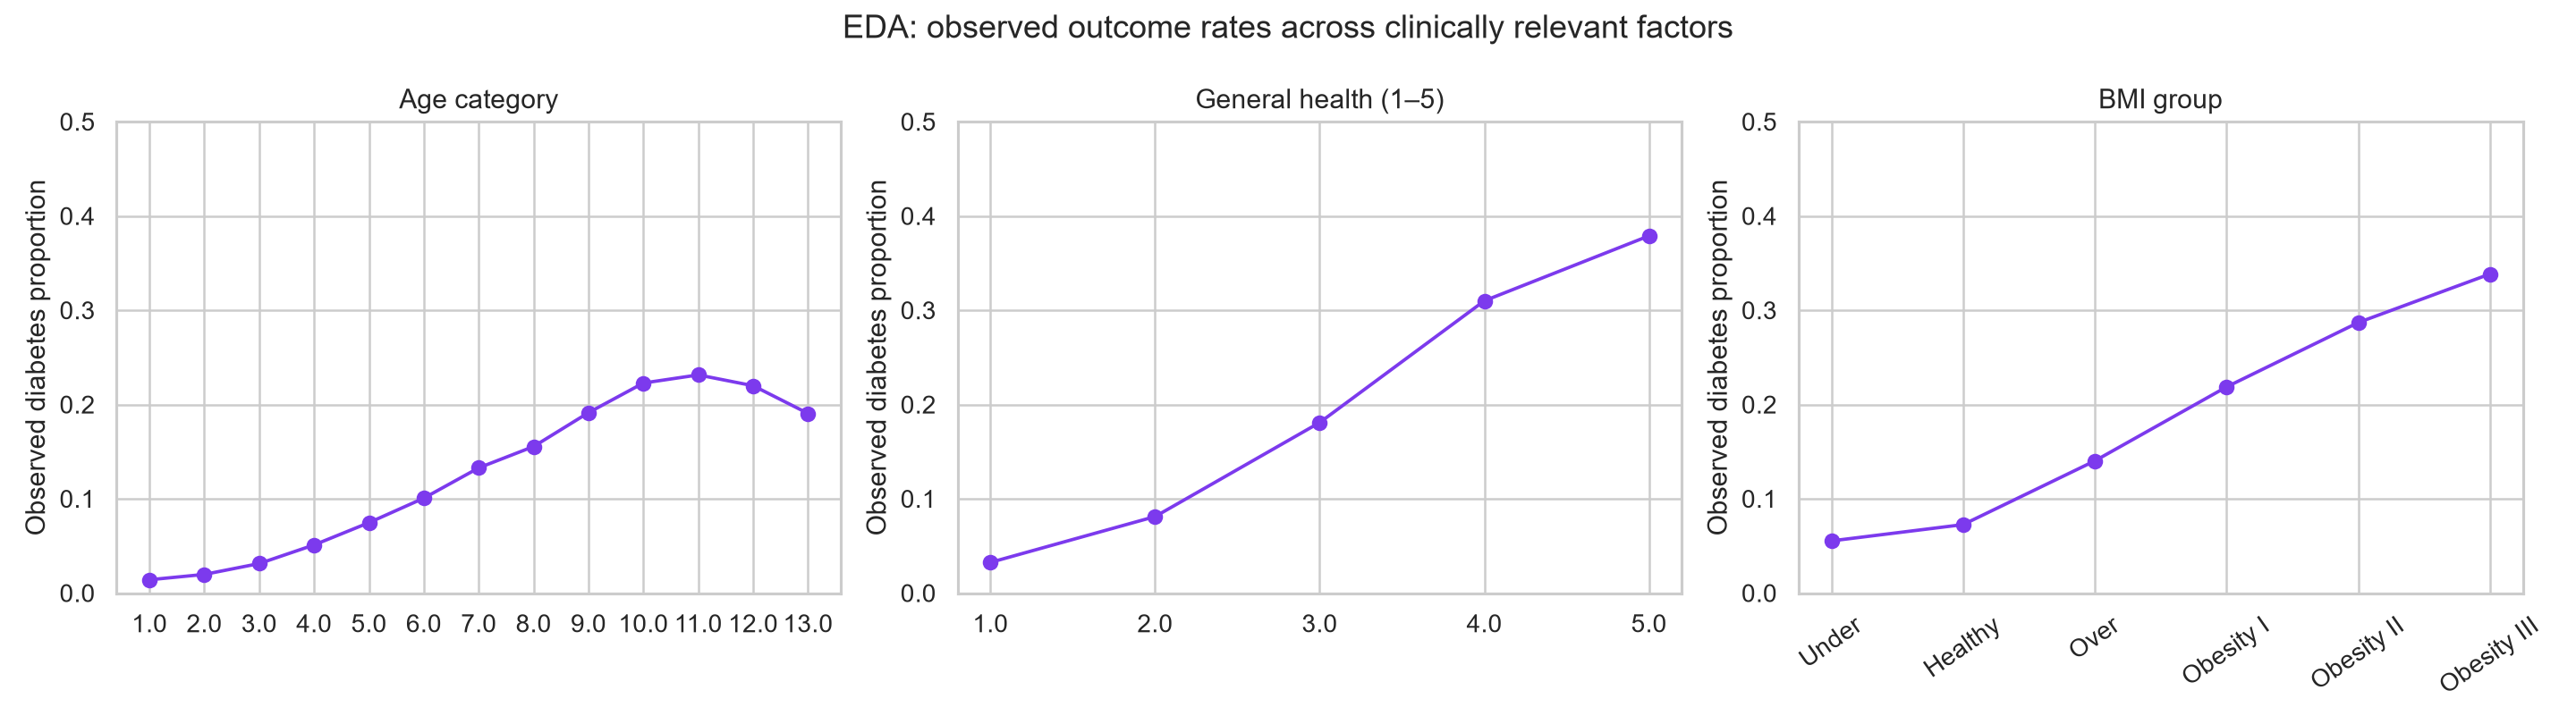

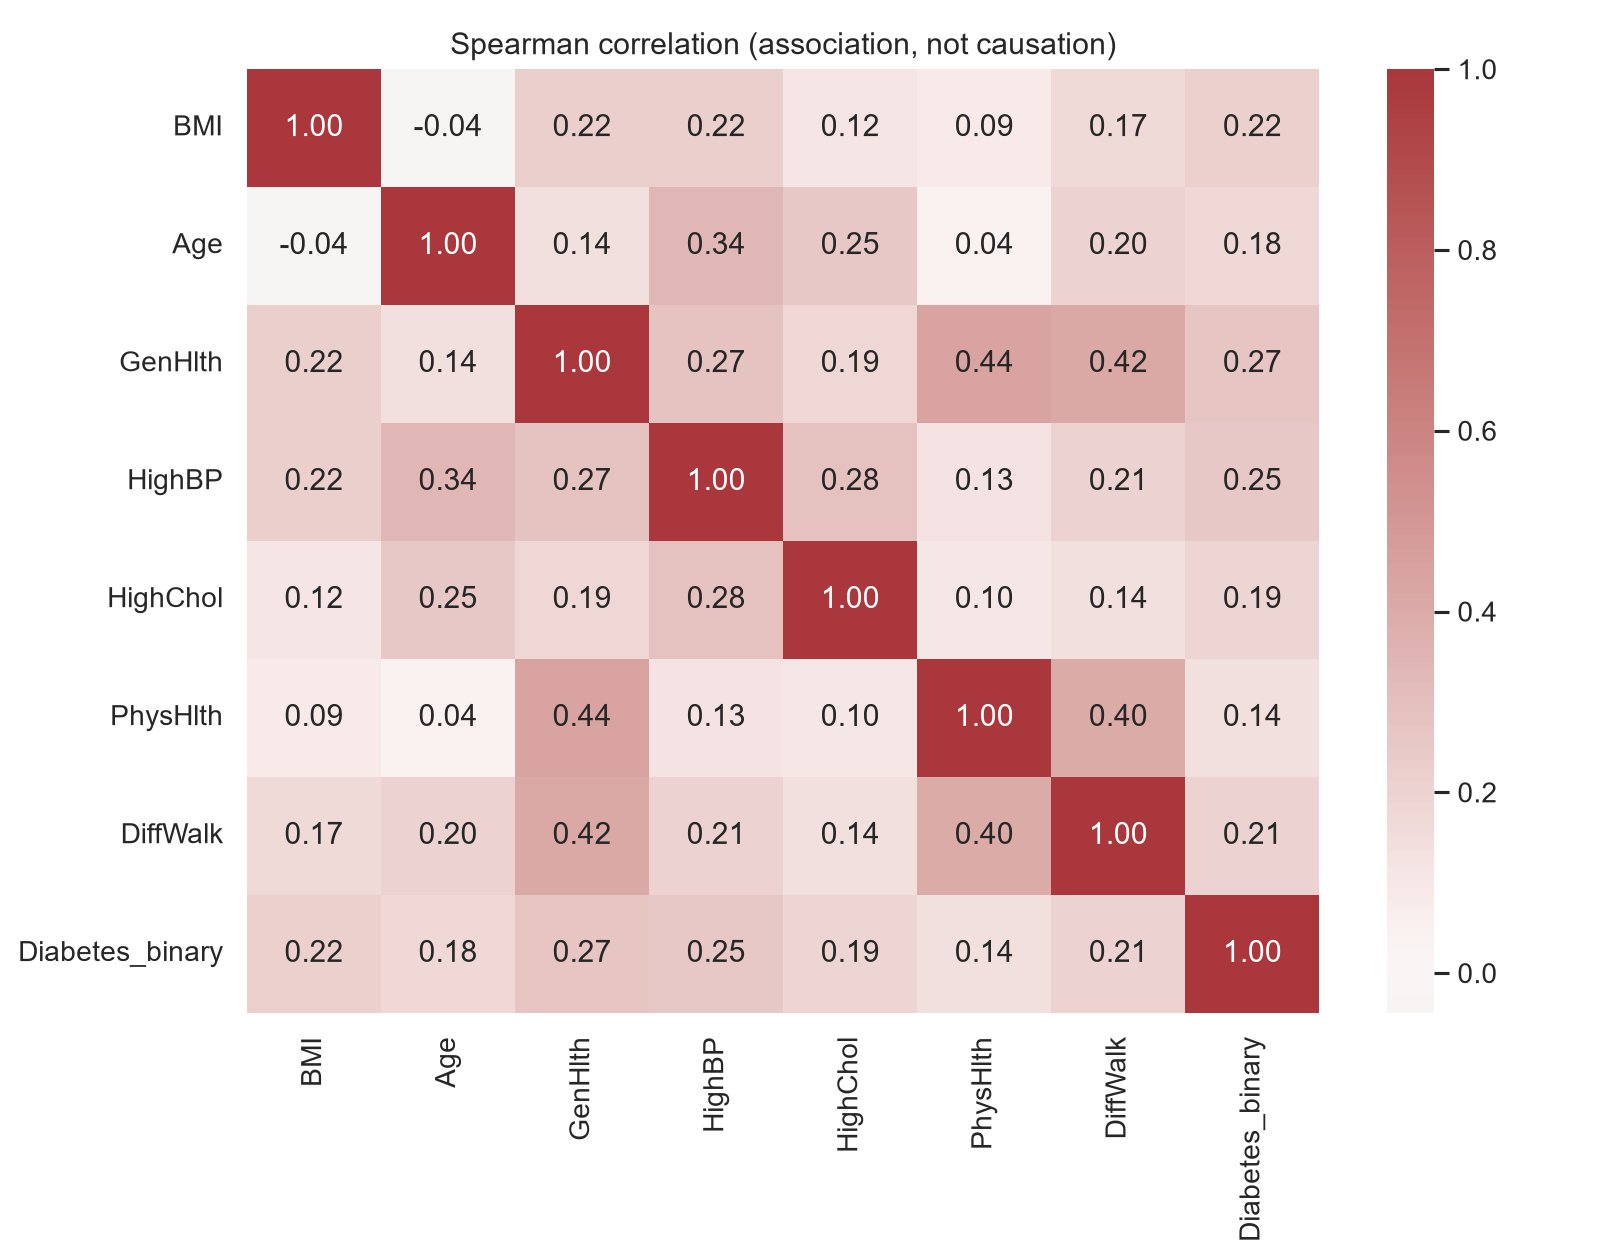

In [3]:
display(Image(filename=str(FIGURES / '01_class_balance.png'), width=650))
display(Image(filename=str(FIGURES / '02_eda_risk_patterns.png'), width=1100))
display(Image(filename=str(FIGURES / '03_correlation_heatmap.png'), width=760))

## Q2 — Data preparation and feature engineering 

- Checked types and allowed ranges for all inputs.
- Missing cells: **0**; the pipeline still handles future missing inputs.
- Removed **24,206 exact duplicates** before splitting.
- Kept valid BMI extremes and used `RobustScaler`.
- Encoded categories and scaled numeric fields inside the pipeline.
- Used balanced weights; avoided SMOTE and fake patient records.
- Added BMI group, unhealthy days, heart count, lifestyle, access and BMI × age.
- Split: stratified **70% train, 15% validation, 15% test**, seed 42.
- Tuning: 3-fold cross-validation on training data only.

In [4]:
from src.modeling import baseline_pipeline
from src.preprocessing import DomainFeatureEngineer, build_preprocessor
print(baseline_pipeline())
print('\nSplit audit:')
display(pd.Series(audit['split']).to_frame('value'))
engineered_preview = DomainFeatureEngineer().fit_transform(df.drop(columns='Diabetes_binary').head(3))
display(engineered_preview[['BMI', 'BMIGroup', 'HealthBurden', 'CardioBurden', 'LifestyleScore', 'AccessBarrier', 'BMIAgeRisk']])

Pipeline(steps=[('features', DomainFeatureEngineer()),
                ('preprocess',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scale',
                                                                   RobustScaler())]),
                                                  ['BMI', 'MentHlth',
                                                   'PhysHlth', 'HealthBurden',
                                                   'CardioBurden',
                                                   'LifestyleScore',
                                                   'AccessBarrier',
                                                   'BM

,value
strategy,"stratified 70/15/15, random_state=42"
train_rows,160631
validation_rows,34421
test_rows,34422
train_positive_rate,0.152947
validation_positive_rate,0.15293
test_positive_rate,0.152955


,BMI,BMIGroup,HealthBurden,CardioBurden,LifestyleScore,AccessBarrier,BMIAgeRisk
0,40.0,obesity_2,33.0,2.0,2.0,0.0,360.0
1,25.0,healthy,0.0,0.0,2.0,1.0,175.0
2,28.0,overweight,60.0,2.0,3.0,1.0,252.0


### Rebuild all results

- Set `RUN_FULL_TRAINING = True` below to run `train.py`.
- It is `False` by default because full training takes several minutes.

In [5]:
RUN_FULL_TRAINING = False
if RUN_FULL_TRAINING:
    import subprocess
    subprocess.run([sys.executable, str(ROOT / 'train.py')], cwd=ROOT, check=True)
else:
    print('Using committed full-run artifacts. Set RUN_FULL_TRAINING=True to regenerate them.')

Using committed full-run artifacts. Set RUN_FULL_TRAINING=True to regenerate them.


## Q3 — Models, tuning and comparison

- **Baseline:** Balanced Logistic Regression.
- **Bagging:** Tuned Random Forest.
- **Boosting:** Tuned AdaBoost.
- **Combined model:** Soft Voting with Logistic Regression, Random Forest and AdaBoost.
- Voting weights: **1 : 2 : 1**; Random Forest gets the highest weight.
- CV tuning used training data only; validation PR-AUC selected the final model.
- Every model used the same untouched test set.
- Validation F2 selected the final screening threshold.

In [6]:
metadata = json.loads((ARTIFACTS / 'model_metadata.json').read_text())
display(Markdown('**Best CV configurations (training partition only)**'))
display(pd.DataFrame({name: {'CV PR-AUC': info['cv_average_precision'], 'parameters': info['best_params']} for name, info in metadata['tuning'].items()}).T)
validation_results = pd.read_csv(TABLES / 'validation_model_comparison.csv')
display(Markdown('**Validation ranking used for model selection**'))
display(validation_results[['model', 'roc_auc', 'average_precision', 'f1', 'precision', 'recall_sensitivity']].style.format(precision=4))

**Best CV configurations (training partition only)**

,CV PR-AUC,parameters
Random Forest,0.424046,"{'model__max_depth': 10, 'model__max_features'..."
AdaBoost,0.409099,"{'model__estimator__max_depth': 2, 'model__lea..."


**Validation ranking used for model selection**

,model,roc_auc,average_precision,f1,precision,recall_sensitivity
0,Soft Voting,0.8169,0.4390,0.4553,0.3224,0.7751
1,Random Forest,0.8155,0.4357,0.4565,0.3256,0.7635
2,Logistic baseline,0.8150,0.4273,0.4549,0.3241,0.7625
3,AdaBoost,0.8112,0.4233,0.4508,0.3182,0.7730


**Untouched test comparison at default threshold 0.50**

,model,roc_auc,average_precision,f1,f2,precision,recall_sensitivity,specificity
0,Soft Voting,0.8135,0.4303,0.4517,0.6025,0.3187,0.7751,0.7008
1,Random Forest,0.8128,0.4299,0.4535,0.5998,0.3224,0.7643,0.7099
2,Logistic baseline,0.8103,0.4147,0.4539,0.6003,0.3227,0.7649,0.7101
3,AdaBoost,0.8077,0.4141,0.4437,0.5939,0.3121,0.7670,0.6948


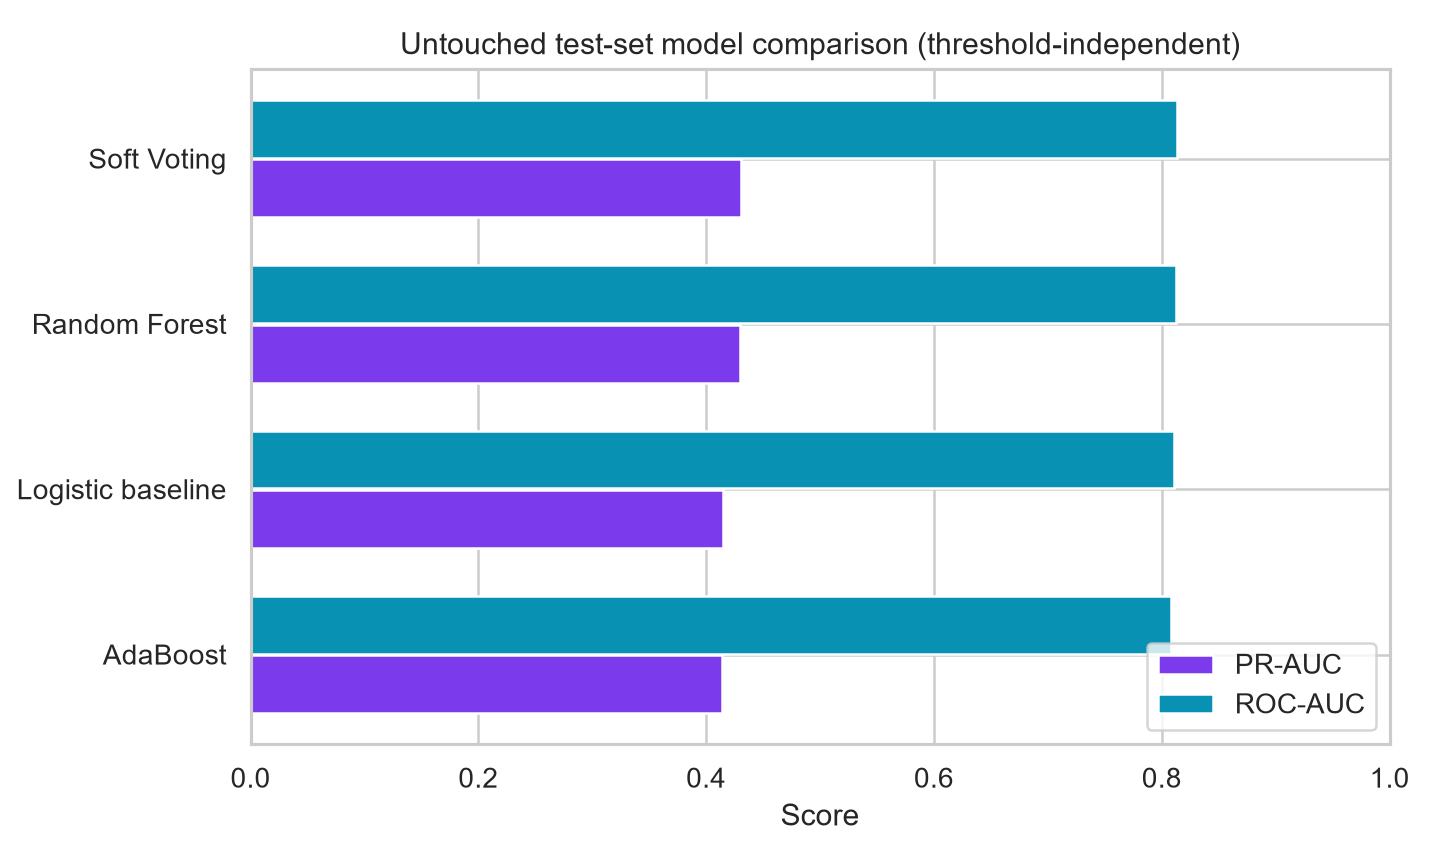

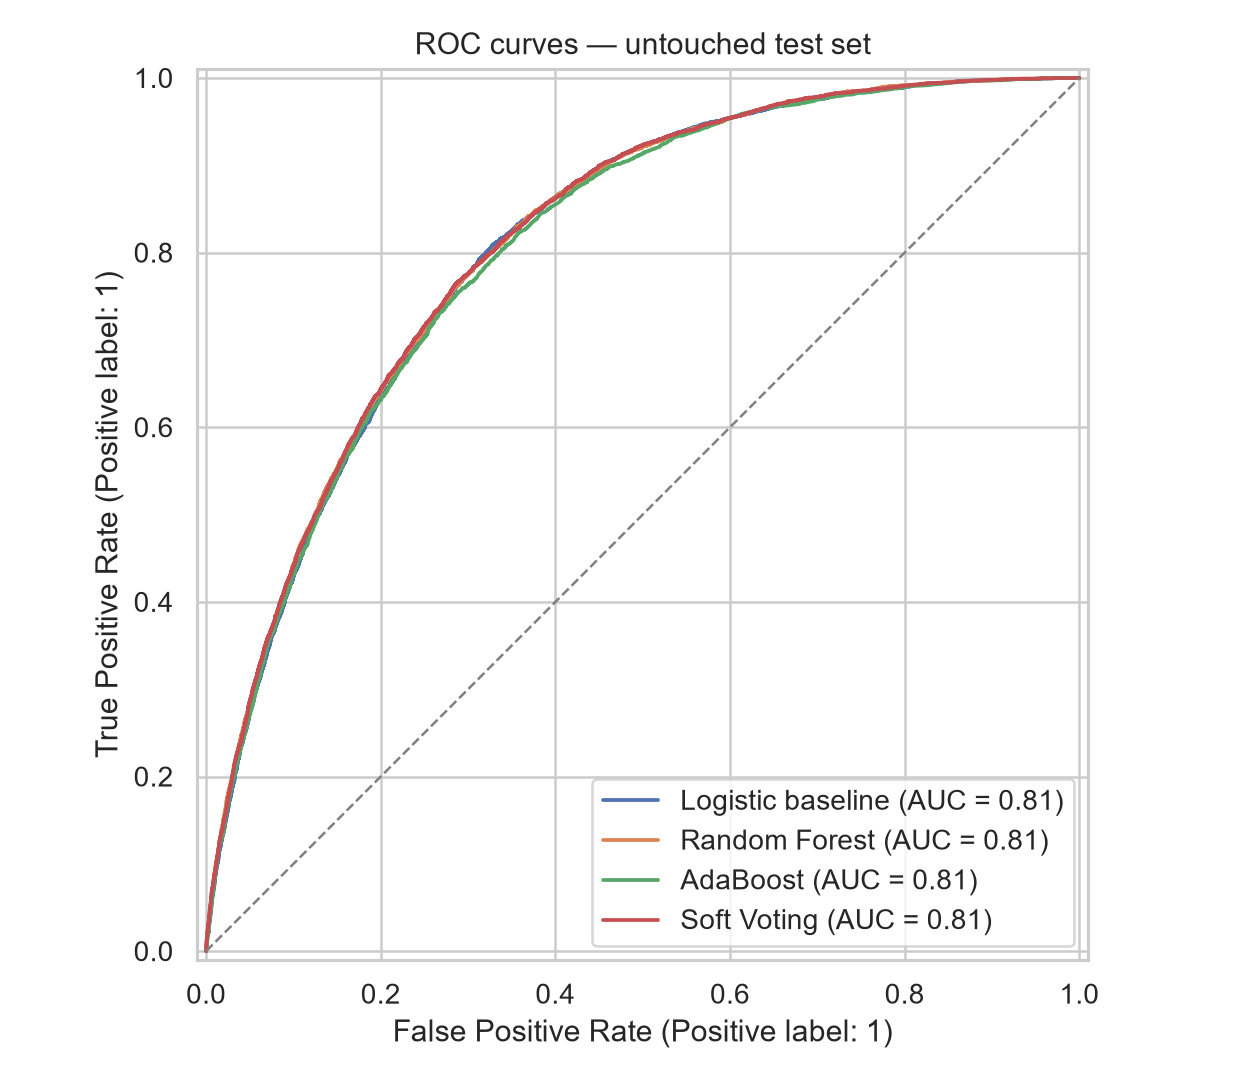

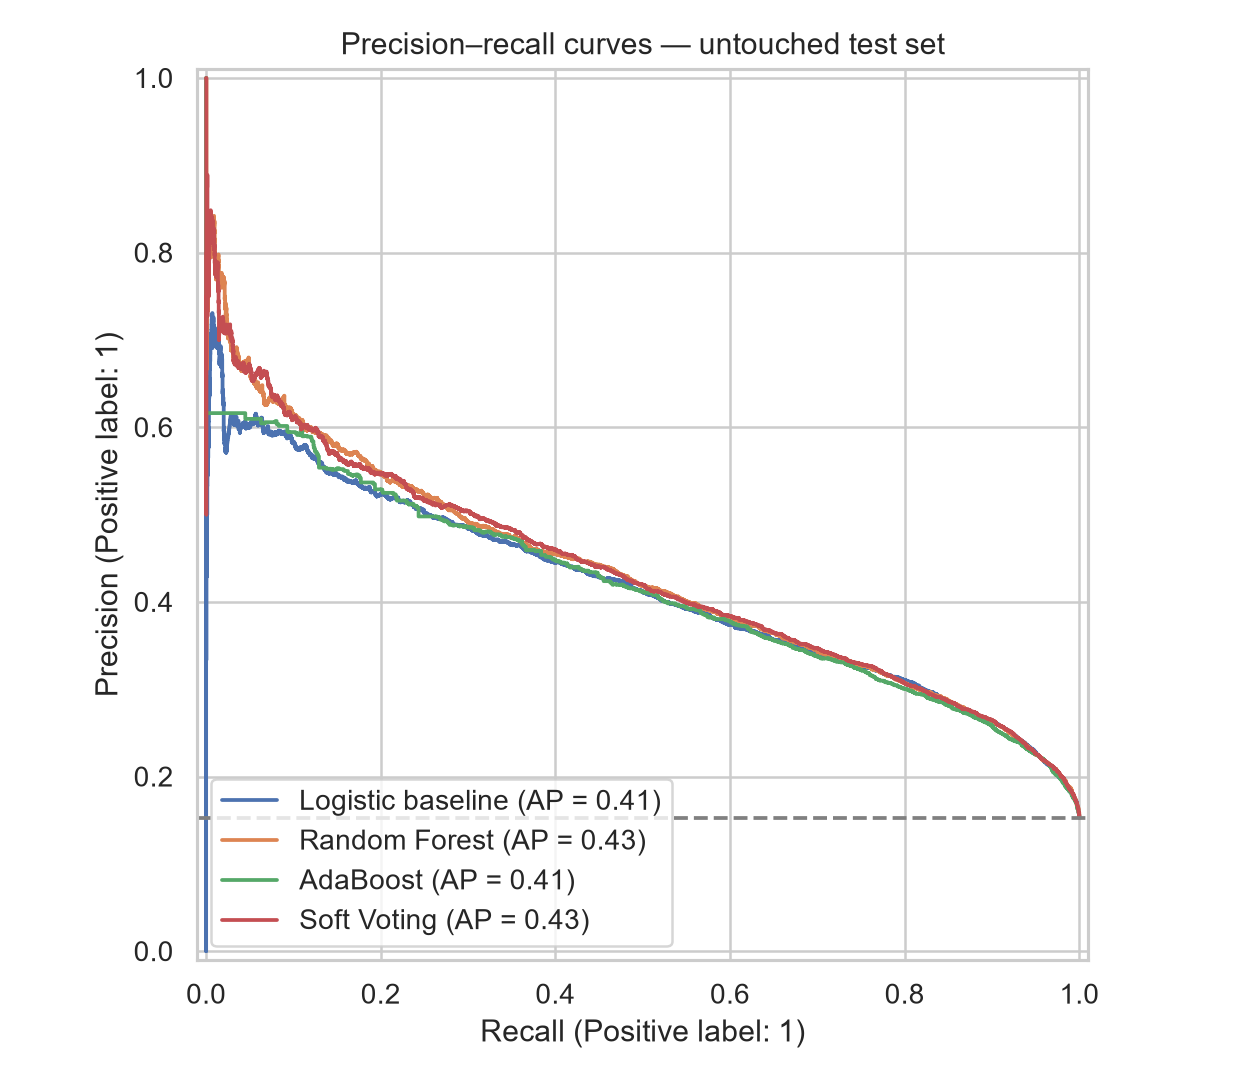

In [7]:
test_results = pd.read_csv(TABLES / 'test_model_comparison.csv')
display(Markdown('**Untouched test comparison at default threshold 0.50**'))
display(test_results[['model', 'roc_auc', 'average_precision', 'f1', 'f2', 'precision', 'recall_sensitivity', 'specificity']].style.format(precision=4).highlight_max(subset=['roc_auc', 'average_precision', 'f1', 'f2']))
display(Image(filename=str(FIGURES / '04_model_comparison.png'), width=760))
display(Image(filename=str(FIGURES / '05_roc_curves.png'), width=650))
display(Image(filename=str(FIGURES / '06_precision_recall_curves.png'), width=650))

### Result summary

- **Best model:** Soft Voting.
- **Soft Voting:** ROC-AUC 0.8135, PR-AUC 0.4303.
- **Logistic baseline:** ROC-AUC 0.8103, PR-AUC 0.4147.
- **PR-AUC gain:** 0.0156 — a small improvement.
- **Threshold:** 0.425, selected using validation data.
- **At this threshold:** Recall 85.3%, precision 28.5%.
- **Errors:** 773 false negatives and 11,265 false positives.
- The score ranks risk; it is not a diagnosis or an exact probability.

,model,threshold,roc_auc,average_precision,f1,f2,precision,recall_sensitivity,specificity,balanced_accuracy,brier_score,tn,fp,fn,tp
0,Soft Voting,0.4250,0.8135,0.4303,0.4274,0.6100,0.2851,0.8532,0.6136,0.7334,0.1833,17892,11265,773,4492


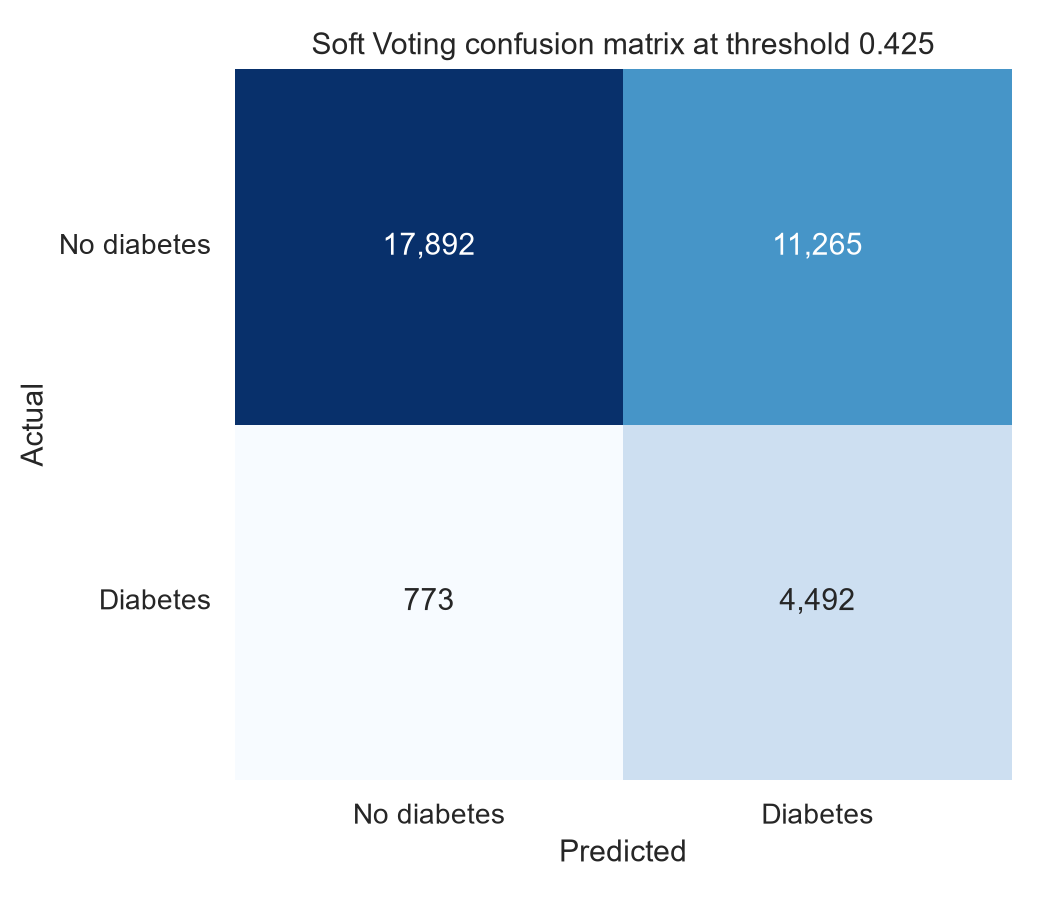

In [8]:
operating = pd.read_csv(TABLES / 'best_model_operating_point.csv')
display(operating.style.format(precision=4))
display(Image(filename=str(FIGURES / '07_best_confusion_matrix.png'), width=540))

## Q4 — Explanation and ethics

- Used SHAP for global and individual explanations.
- **Top features:** General health, high BP, BMI, age and high cholesterol.
- **Demo:** BMI, high BP, general health and cholesterol raise the score most.
- SHAP explains model behavior, not cause and effect.
- Recall: 51.3% for ages 18–44 and 90.8% for ages 65+.
- False negatives delay care; false positives add cost and workload.
- Protect data with consent, encryption and limited access.
- Limits: Self-reported 2015 US data, no local testing or score calibration.
- A doctor must review every result.

,feature,mean_absolute_shap
0,GenHlth,0.0791
1,HighBP,0.0652
2,BMI,0.0603
3,Age,0.0579
4,HighChol,0.0466
5,HeartDiseaseorAttack,0.0104
6,Income,0.0090
7,Sex,0.0089
8,DiffWalk,0.0084
9,CholCheck,0.0084


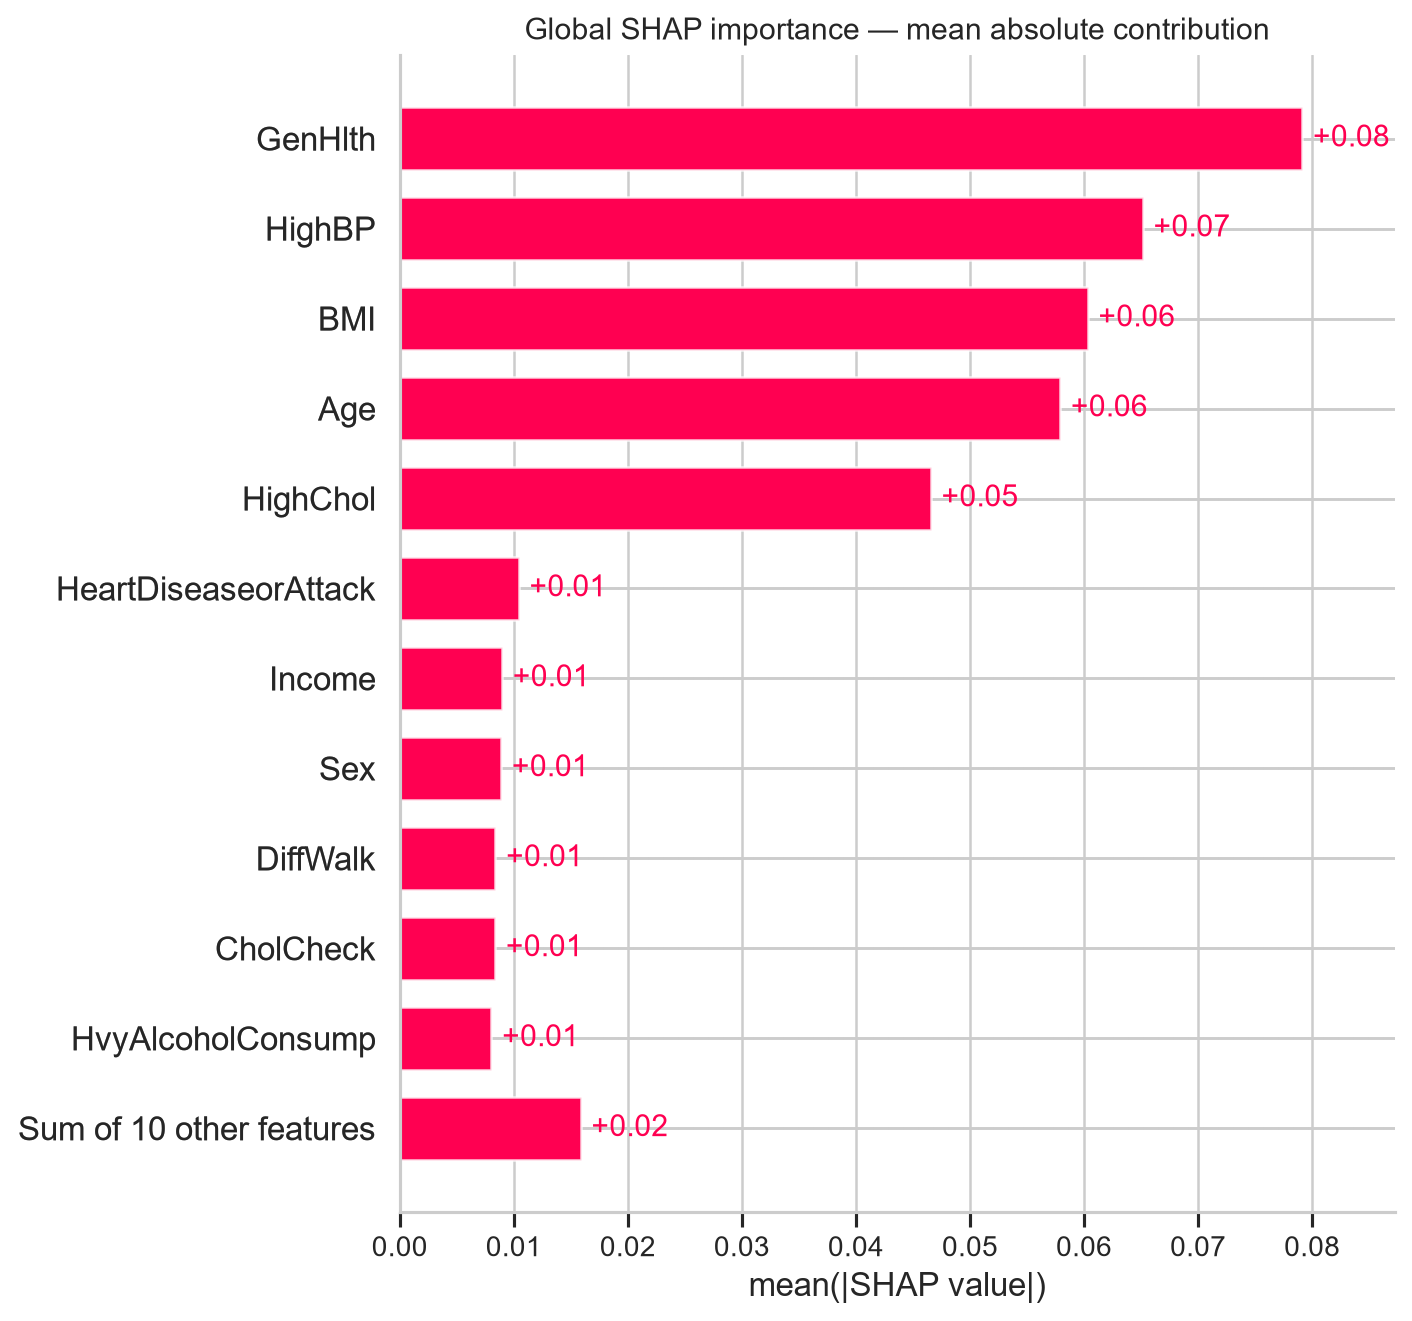

,feature,value,shap_contribution
0,BMI,34,+0.1204
1,HighBP,1,+0.0825
2,GenHlth,3,+0.0806
3,HighChol,1,+0.0679
4,Age,8,+0.0144
5,Income,5,+0.0065
6,HvyAlcoholConsump,0,+0.0060
7,DiffWalk,0,-0.0057
8,Sex,0,-0.0055
9,CholCheck,1,+0.0049


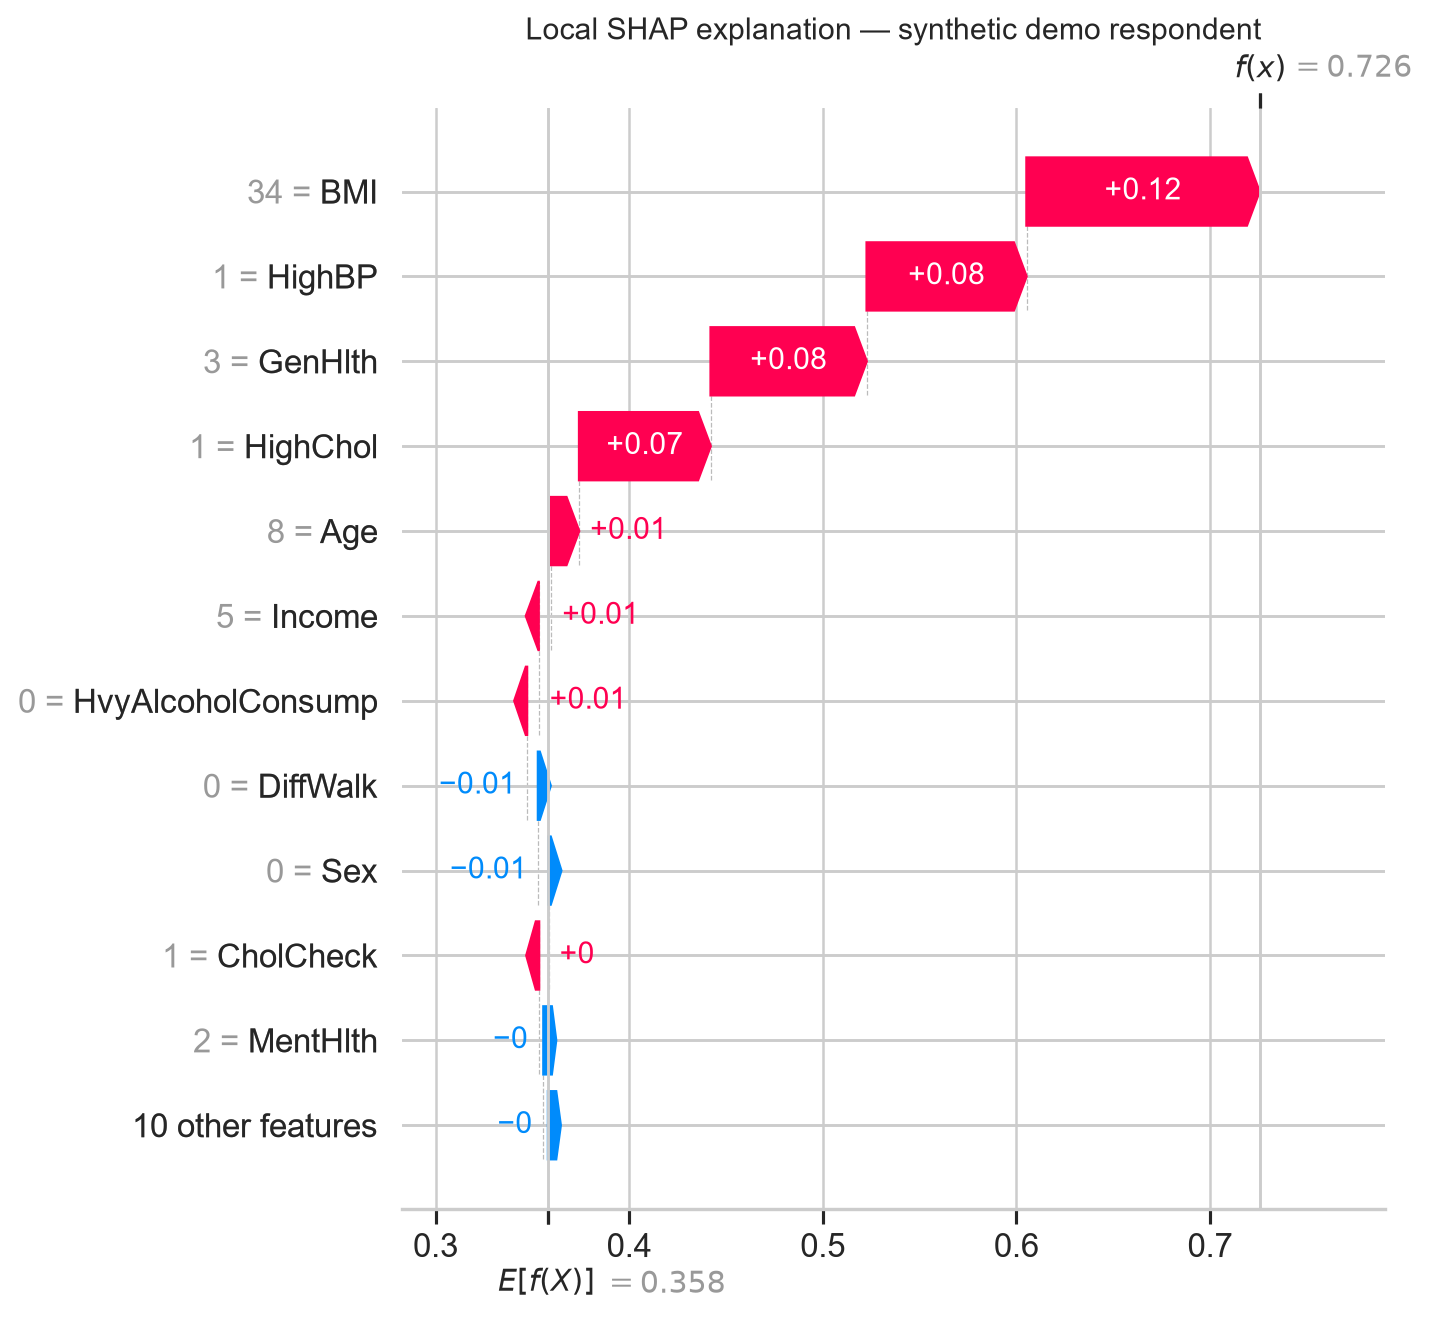

In [9]:
global_shap = pd.read_csv(TABLES / 'shap_global_importance.csv')
local_shap = pd.read_csv(TABLES / 'shap_demo_local.csv')
display(global_shap.head(10).style.format({'mean_absolute_shap': '{:.4f}'}))
display(Image(filename=str(FIGURES / '09_shap_global.png'), width=780))
display(local_shap.head(10).style.format({'shap_contribution': '{:+.4f}'}))
display(Image(filename=str(FIGURES / '10_shap_local_demo.png'), width=820))

,attribute,group,n,prevalence,selection_rate,roc_auc,precision,recall_tpr,false_positive_rate
0,Sex,Female,19235,0.143,0.433,0.822,0.280,0.848,0.364
1,Sex,Male,15187,0.166,0.489,0.803,0.291,0.859,0.416
2,Age band,18–44,7253,0.048,0.099,0.851,0.247,0.513,0.078
3,Age band,45–64,14508,0.153,0.436,0.819,0.295,0.839,0.363
4,Age band,65+,12661,0.213,0.688,0.745,0.281,0.908,0.628
5,Income band,Higher income codes 5–8,25747,0.128,0.400,0.818,0.262,0.823,0.339
6,Income band,Lower income codes 1–4,8675,0.228,0.628,0.774,0.328,0.903,0.547


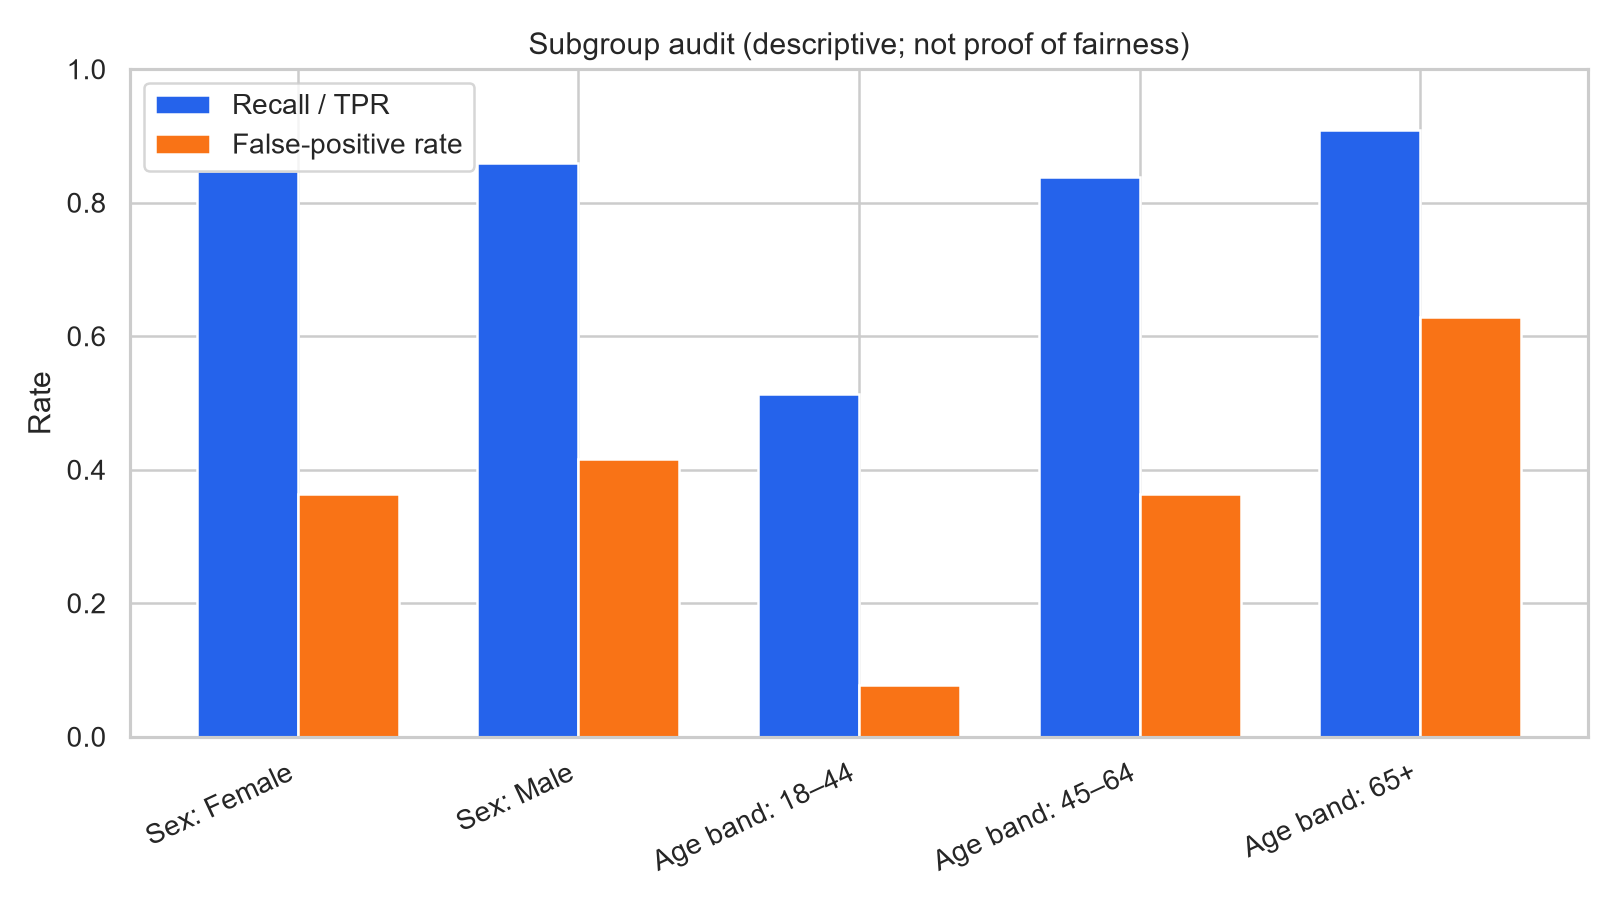

In [10]:
fairness = pd.read_csv(TABLES / 'fairness_subgroups.csv')
display(fairness.style.format({column: '{:.3f}' for column in ['prevalence', 'selection_rate', 'roc_auc', 'precision', 'recall_tpr', 'false_positive_rate']}))
display(Image(filename=str(FIGURES / '08_fairness_audit.png'), width=820))

## Q5 — Live prediction and video 

- Uses a fake patient record with no personal data.
- The saved pipeline handles all features and gives the prediction.
- Score **≥ 0.425** means screen positive and needs further testing.
- See `VIDEO_SCRIPT.md` for the three-minute video plan.

In [11]:
from src.config import RAW_FEATURES
record = json.loads((ROOT / 'examples' / 'synthetic_record.json').read_text())
model = joblib.load(ARTIFACTS / 'diabetes_screening_pipeline.joblib')
score = float(model.predict_proba(pd.DataFrame([record], columns=RAW_FEATURES))[0, 1])
threshold = float(metadata['operating_threshold'])
display(pd.Series(record, name='synthetic value').to_frame())
print(f'Model risk-ranking score: {score:.3f}')
print(f'Validation-selected threshold: {threshold:.3f}')
print('Screen result:', 'POSITIVE — prioritize confirmatory assessment' if score >= threshold else 'NEGATIVE — routine care still applies')
print('DISCLAIMER: This is not a diagnosis or calibrated future-risk probability; clinician review is required.')

,synthetic value
HighBP,1
HighChol,1
CholCheck,1
BMI,34
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,1
Veggies,1


Model risk-ranking score: 0.726
Validation-selected threshold: 0.425
Screen result: POSITIVE — prioritize confirmatory assessment
DISCLAIMER: This is not a diagnosis or calibrated future-risk probability; clinician review is required.


## Conclusion

- Soft Voting performed slightly better than Logistic Regression.
- The selected threshold finds more positive cases but creates many false positives.
- The model needs doctor review, local testing and fairness checks before real use.